# NB09 - BC_CinePartition static blob-frame exploration

## Purpose

This notebook explores Mindray TE7 native `BC_CinePartition*.bin` files as static blob / frame candidates.

The main goal is to test whether the BC cine partition contains image-like data that could represent:

- a static B-mode frame,
- a crop or mask,
- a pixel buffer,
- a compressed frame-like payload,
- or an unusable binary blob.

This notebook is exploratory. It does **not** claim decoded native image data unless visual and structural evidence supports that interpretation.


## Expected outputs

Potential outputs, only if useful:

```text
reports/nb09_bc_cine/nb09_bc_cine_inventory.csv
reports/nb09_bc_cine/nb09_bc_cine_entropy_summary.csv
figures/nb09_bc_cine/
docs/nb09_bc_cine/nb09_bc_cine_checkpoint.md

## Imports & Setup

In [22]:
from pathlib import Path
import math, warnings, cv2
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NB09 - BC_CinePartition static blob-frame exploration

SAVE_OUTPUTS = False
MAX_BYTES_FOR_QUICK_SCAN = 2_000_000
ENTROPY_SAMPLE_BYTES = 1_000_000
BYTE_HISTOGRAM_BINS = 256

CANDIDATE_IMAGE_WIDTHS = [256, 320, 384, 480, 512, 640, 720, 768, 800, 960, 1024, 1280]
CANDIDATE_PIXEL_DTYPES = ["uint8", "uint16_le", "uint16_be"]

## BC_CinePartition file discovery

This section discovers `BC_CinePartition*.bin` files across the native recording batch.

Main goal:

- check whether BC cine files are consistently present,
- record file names and sizes,
- compare BC availability against PW cine and linked AVI availability.

Important:

This is only file discovery. It does not inspect image content yet and does not claim that the BC partition contains a decoded frame.

In [3]:
def resolve_project_root(candidate_roots=None):
    """
    Resolve the DopplerLab project root.

    A valid root should contain at least one known project directory or notebook.
    This function does not create or modify files.
    """
    if candidate_roots is None:
        candidate_roots = [
            Path(r"E:\DopplerLab"),
            Path(r"D:\code\DopplerLab"),
            Path.cwd(),
            Path.cwd().parent,
        ]

    checked = []

    for root in candidate_roots:
        root = Path(root)
        checked.append(str(root))

        if not root.exists():
            continue

        expected_any = [
            root / "ultrasound_recordings",
            root / "reports",
            root / "NB08 - FeParam metadata extraction.ipynb",
            root / "AGENTS.md",
        ]

        if any(path.exists() for path in expected_any):
            return root

    raise FileNotFoundError(
        "Could not resolve DopplerLab project root. Checked:\n"
        + "\n".join(checked)
    )


def build_nb09_paths(project_root):
    """
    Build paths for NB09 BC_CinePartition exploration.

    This only defines paths. It does not create directories.
    """
    project_root = Path(project_root)

    paths = {
        "PROJECT_ROOT": project_root,
        "NATIVE_BATCH_DIR": project_root / "ultrasound_recordings" / "batch_2026_06_13_native",

        "NB09_REPORTS_DIR": project_root / "reports" / "nb09_bc_cine",
        "NB09_FIGURES_DIR": project_root / "figures" / "nb09_bc_cine",
        "NB09_DOCS_DIR": project_root / "docs" / "nb09_bc_cine",

        # Useful previous checkpoint outputs, optional.
        "NB06_V2_DIAGNOSTIC_TABLE": project_root / "reports" / "nb06_v2" / "nb06_v2_recording_diagnostic.csv",
        "NB06_V2_COMPACT_CONTROL_TABLE": project_root / "reports" / "nb06_v2" / "nb06_v2_compact_control_table.csv",
        "NB08_FEPARAM_BLOB_INVENTORY": project_root / "reports" / "nb08_feparam" / "nb08_feparam_blob_inventory.csv",
    }

    return paths


def build_path_status_table(paths):
    """
    Build a path status table for NB09 dependencies and outputs.
    """
    required = {
        "PROJECT_ROOT",
        "NATIVE_BATCH_DIR",
    }

    optional_previous_outputs = {
        "NB06_V2_DIAGNOSTIC_TABLE",
        "NB06_V2_COMPACT_CONTROL_TABLE",
        "NB08_FEPARAM_BLOB_INVENTORY",
    }

    outputs = {
        "NB09_REPORTS_DIR",
        "NB09_FIGURES_DIR",
        "NB09_DOCS_DIR",
    }

    rows = []

    for key, path in paths.items():
        path = Path(path)

        if key in required:
            role = "required"
        elif key in optional_previous_outputs:
            role = "optional_previous_output"
        elif key in outputs:
            role = "output_not_created_by_setup"
        else:
            role = "support"

        rows.append(
            {
                "key": key,
                "role": role,
                "exists": path.exists(),
                "is_dir": path.is_dir() if path.exists() else False,
                "path": str(path),
            }
        )

    return pd.DataFrame(rows).sort_values(["role", "key"]).reset_index(drop=True)


def print_nb09_setup_summary(project_root, paths, status_df):
    """
    Print a compact setup summary.
    """
    print("NB09 BC_CinePartition setup")
    print("=" * 80)
    print(f"PROJECT_ROOT: {project_root}")
    print(f"SAVE_OUTPUTS: {SAVE_OUTPUTS}")
    print()

    missing_required = status_df[
        (status_df["role"] == "required") & (~status_df["exists"])
    ]

    print(f"Missing required paths: {len(missing_required)}")
    print()

    if len(missing_required) > 0:
        display(missing_required)

    print("Output paths defined but not created by setup:")
    for key in ["NB09_REPORTS_DIR", "NB09_FIGURES_DIR", "NB09_DOCS_DIR"]:
        print(f"  - {key}: {paths[key]}")

In [4]:
PROJECT_ROOT = resolve_project_root()
PATHS = build_nb09_paths(PROJECT_ROOT)
path_status_df = build_path_status_table(PATHS)

print_nb09_setup_summary(project_root=PROJECT_ROOT, paths=PATHS, status_df=path_status_df)
path_status_df

NB09 BC_CinePartition setup
PROJECT_ROOT: E:\DopplerLab
SAVE_OUTPUTS: False

Missing required paths: 0

Output paths defined but not created by setup:
  - NB09_REPORTS_DIR: E:\DopplerLab\reports\nb09_bc_cine
  - NB09_FIGURES_DIR: E:\DopplerLab\figures\nb09_bc_cine
  - NB09_DOCS_DIR: E:\DopplerLab\docs\nb09_bc_cine


,key,role,exists,is_dir,path
0,NB06_V2_COMPACT_CONTROL_TABLE,optional_previous_output,True,False,E:\DopplerLab\reports\nb06_v2\nb06_v2_compact_...
1,NB06_V2_DIAGNOSTIC_TABLE,optional_previous_output,True,False,E:\DopplerLab\reports\nb06_v2\nb06_v2_recordin...
2,NB08_FEPARAM_BLOB_INVENTORY,optional_previous_output,True,False,E:\DopplerLab\reports\nb08_feparam\nb08_fepara...
3,NB09_DOCS_DIR,output_not_created_by_setup,False,False,E:\DopplerLab\docs\nb09_bc_cine
4,NB09_FIGURES_DIR,output_not_created_by_setup,False,False,E:\DopplerLab\figures\nb09_bc_cine
5,NB09_REPORTS_DIR,output_not_created_by_setup,False,False,E:\DopplerLab\reports\nb09_bc_cine
6,NATIVE_BATCH_DIR,required,True,True,E:\DopplerLab\ultrasound_recordings\batch_2026...
7,PROJECT_ROOT,required,True,True,E:\DopplerLab


In [5]:
def find_first_existing_file(folder, candidate_names=None, glob_patterns=None):
    """
    Find the first matching file in a folder using exact names first,
    then glob patterns.

    Parameters
    ----------
    folder : pathlib.Path or str
        Folder to search.

    candidate_names : list[str] or None
        Exact file names to check first.

    glob_patterns : list[str] or None
        Glob patterns to search if exact names are not found.

    Returns
    -------
    pathlib.Path or None
        First matching file, or None.
    """
    folder = Path(folder)

    if not folder.exists() or not folder.is_dir():
        return None

    if candidate_names is not None:
        for name in candidate_names:
            candidate = folder / name
            if candidate.exists() and candidate.is_file():
                return candidate

    if glob_patterns is not None:
        for pattern in glob_patterns:
            matches = sorted(path for path in folder.glob(pattern) if path.is_file())
            if len(matches) > 0:
                return matches[0]

    return None


def safe_file_size(path):
    """
    Return file size in bytes, or None if the path is missing.
    """
    if path is None:
        return None

    path = Path(path)

    if not path.exists() or not path.is_file():
        return None

    return int(path.stat().st_size)


def discover_bc_cine_inventory(native_batch_dir):
    """
    Discover BC_CinePartition files in a native Mindray batch.

    Parameters
    ----------
    native_batch_dir : pathlib.Path or str
        Batch directory containing one folder per recording.

    Returns
    -------
    pandas.DataFrame
        One row per recording.
    """
    native_batch_dir = Path(native_batch_dir)

    if not native_batch_dir.exists():
        raise FileNotFoundError(f"Native batch directory not found: {native_batch_dir}")

    recording_dirs = sorted(path for path in native_batch_dir.iterdir() if path.is_dir())

    rows = []

    for recording_dir in recording_dirs:
        recording_id = recording_dir.name
        native_dir = recording_dir / "native"

        bc_path = find_first_existing_file(
            native_dir,
            candidate_names=["BC_CinePartition1.bin"],
            glob_patterns=["BC_CinePartition*.bin"],
        )

        pw_path = find_first_existing_file(
            native_dir,
            candidate_names=["PW_CinePartition0.bin"],
            glob_patterns=["PW_CinePartition*.bin"],
        )

        linked_avi_path = find_first_existing_file(
            recording_dir / "linked_avi",
            candidate_names=[f"{recording_id}.avi"],
            glob_patterns=["*.avi", "*.mp4"],
        )

        bc_size = safe_file_size(bc_path)
        pw_size = safe_file_size(pw_path)
        avi_size = safe_file_size(linked_avi_path)

        rows.append(
            {
                "recording_id": recording_id,
                "native_dir_exists": native_dir.exists(),
                "has_bc_cine": bc_path is not None,
                "bc_file_name": bc_path.name if bc_path is not None else "",
                "bc_path": str(bc_path) if bc_path is not None else "",
                "bc_size_bytes": bc_size,
                "bc_size_kb": round(bc_size / 1024, 2) if bc_size is not None else None,
                "bc_size_mb": round(bc_size / (1024 ** 2), 4) if bc_size is not None else None,
                "has_pw_cine": pw_path is not None,
                "pw_size_bytes": pw_size,
                "pw_size_mb": round(pw_size / (1024 ** 2), 4) if pw_size is not None else None,
                "has_linked_avi": linked_avi_path is not None,
                "linked_avi_size_mb": round(avi_size / (1024 ** 2), 4) if avi_size is not None else None,
            }
        )

    return pd.DataFrame(rows).sort_values("recording_id").reset_index(drop=True)


def summarize_bc_cine_inventory(bc_inventory_df):
    """
    Print a compact summary of BC_CinePartition availability and sizes.
    """
    print("BC_CinePartition inventory")
    print("=" * 80)
    print(f"Recordings: {len(bc_inventory_df)}")

    if len(bc_inventory_df) == 0:
        return

    print(f"Has BC cine: {int(bc_inventory_df['has_bc_cine'].sum())}/{len(bc_inventory_df)}")
    print(f"Has PW cine: {int(bc_inventory_df['has_pw_cine'].sum())}/{len(bc_inventory_df)}")
    print(f"Has linked AVI: {int(bc_inventory_df['has_linked_avi'].sum())}/{len(bc_inventory_df)}")
    print()

    present_df = bc_inventory_df[bc_inventory_df["has_bc_cine"]].copy()

    if len(present_df) == 0:
        print("No BC_CinePartition files found.")
        return

    print("BC size summary:")
    display(
        present_df["bc_size_bytes"]
        .describe()
        .to_frame(name="bc_size_bytes")
    )

    print()
    print("BC file name counts:")
    display(present_df["bc_file_name"].value_counts().to_frame(name="count"))

    print()
    print("Inventory preview:")
    display(
        bc_inventory_df[
            [
                "recording_id",
                "has_bc_cine",
                "bc_file_name",
                "bc_size_bytes",
                "bc_size_mb",
                "has_pw_cine",
                "pw_size_mb",
                "has_linked_avi",
            ]
        ]
    )


In [6]:
bc_inventory_df = discover_bc_cine_inventory(PATHS["NATIVE_BATCH_DIR"])
summarize_bc_cine_inventory(bc_inventory_df)

bc_inventory_df

BC_CinePartition inventory
Recordings: 10
Has BC cine: 10/10
Has PW cine: 10/10
Has linked AVI: 10/10

BC size summary:


,bc_size_bytes
count,10.000000
mean,180140.000000
std,18252.666654
min,174368.000000
25%,174368.000000
50%,174368.000000
75%,174368.000000
max,232088.000000



BC file name counts:


,count
bc_file_name,
BC_CinePartition1.bin,10



Inventory preview:


,recording_id,has_bc_cine,bc_file_name,bc_size_bytes,bc_size_mb,has_pw_cine,pw_size_mb,has_linked_avi
0,202606130411060002SMP,True,BC_CinePartition1.bin,174368,0.1663,True,36.6030,True
1,202606130413540003SMP,True,BC_CinePartition1.bin,174368,0.1663,True,29.0340,True
2,202606130417060004SMP,True,BC_CinePartition1.bin,174368,0.1663,True,26.2419,True
3,202606130420260005SMP,True,BC_CinePartition1.bin,174368,0.1663,True,28.1354,True
4,202606130422440006SMP,True,BC_CinePartition1.bin,174368,0.1663,True,31.6728,True
5,202606130426500007SMP,True,BC_CinePartition1.bin,174368,0.1663,True,22.6750,True
6,202606130430380008SMP,True,BC_CinePartition1.bin,174368,0.1663,True,27.4211,True
7,202606130433280009SMP,True,BC_CinePartition1.bin,174368,0.1663,True,19.6048,True
8,202606130434130010SMP,True,BC_CinePartition1.bin,174368,0.1663,True,20.9075,True
9,202606130437480012SMP,True,BC_CinePartition1.bin,232088,0.2213,True,27.8252,True


,recording_id,native_dir_exists,has_bc_cine,bc_file_name,bc_path,bc_size_bytes,bc_size_kb,bc_size_mb,has_pw_cine,pw_size_bytes,pw_size_mb,has_linked_avi,linked_avi_size_mb
0,202606130411060002SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,38381040,36.6030,True,14.1303
1,202606130413540003SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,30444336,29.0340,True,12.2503
2,202606130417060004SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,27516672,26.2419,True,8.8570
3,202606130420260005SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,29502144,28.1354,True,14.9465
4,202606130422440006SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,33211296,31.6728,True,15.0892
5,202606130426500007SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,23776416,22.6750,True,12.0533
6,202606130430380008SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,28753056,27.4211,True,9.5882
7,202606130433280009SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,20557152,19.6048,True,12.6586
8,202606130434130010SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,174368,170.28,0.1663,True,21923136,20.9075,True,13.3452
9,202606130437480012SMP,True,True,BC_CinePartition1.bin,E:\DopplerLab\ultrasound_recordings\batch_2026...,232088,226.65,0.2213,True,29176848,27.8252,True,9.3911


### BC inventory interpretation

Result classification: useful positive result.

`BC_CinePartition1.bin` is present in all 10 native recordings, and the file name is consistent across the batch.

Nine recordings have the same BC file size: `174,368` bytes. One recording, `202606130437480012SMP`, is larger at `232,088` bytes.

This suggests that BC data is mostly fixed-size in this batch, unlike PW cine files, which vary with recording duration. The larger BC file is treated as an exception case that may contain extra blocks, padding, or a different acquisition layout.

This result supports continuing with byte-level structure checks before any image-like reshape attempt.

## BC byte distribution and entropy diagnostics

This section treats each BC file as raw bytes and measures basic byte-distribution properties.

Main goal:

- estimate Shannon entropy in bits per byte,
- measure zero-byte and `0xFF` fractions,
- list the most frequent byte values,
- identify whether files look sparse, structured, compressed-like, or random-like.

Interpretation guide:

- very low entropy suggests padding, repeated values, or sparse structures,
- moderate entropy can be consistent with structured binary data, raw-ish image-like data, metadata, or mixed payloads,
- very high entropy near 8 bits/byte can suggest compressed, encrypted, or noise-like data.

Important:

Entropy does not prove that data is image-like. It only helps decide which next experiment is reasonable.

In [7]:
def compute_shannon_entropy(byte_data):
    """
    Compute Shannon entropy in bits per byte.
    """
    if byte_data is None or len(byte_data) == 0:
        return None

    values = np.frombuffer(byte_data, dtype=np.uint8)
    counts = np.bincount(values, minlength=256)
    probabilities = counts[counts > 0] / len(values)
    entropy = -np.sum(probabilities * np.log2(probabilities))

    return float(entropy)


def summarize_byte_distribution(byte_data):
    """
    Build compact byte-distribution diagnostics for one byte buffer.
    """
    values = np.frombuffer(byte_data, dtype=np.uint8)
    counts = np.bincount(values, minlength=256)

    total = len(values)
    nonzero_counts = counts[counts > 0]

    top_indices = np.argsort(counts)[::-1][:12]
    top_bytes = [
        {
            "byte": int(byte),
            "hex": f"0x{byte:02X}",
            "count": int(counts[byte]),
            "fraction": float(counts[byte] / total),
        }
        for byte in top_indices
        if counts[byte] > 0
    ]

    return {
        "n_bytes": int(total),
        "entropy_bits_per_byte": compute_shannon_entropy(byte_data),
        "unique_byte_values": int((counts > 0).sum()),
        "zero_fraction": float(counts[0] / total),
        "ff_fraction": float(counts[255] / total),
        "min_byte": int(values.min()),
        "max_byte": int(values.max()),
        "mean_byte": float(values.mean()),
        "std_byte": float(values.std()),
        "top_bytes": top_bytes,
    }


def build_bc_byte_summary(bc_inventory_df, max_bytes=None):
    """
    Compute byte-distribution summary for each BC_CinePartition file.

    Parameters
    ----------
    bc_inventory_df : pandas.DataFrame
        Output from discover_bc_cine_inventory.

    max_bytes : int or None
        If provided, only the first max_bytes are read from each file.
        Use None for full-file summary.

    Returns
    -------
    tuple[pandas.DataFrame, pandas.DataFrame]
        Summary table and top-byte table.
    """
    summary_rows = []
    top_byte_rows = []

    present_df = bc_inventory_df[bc_inventory_df["has_bc_cine"]].copy()

    for _, row in present_df.iterrows():
        recording_id = row["recording_id"]
        bc_path = Path(row["bc_path"])

        with open(bc_path, "rb") as file:
            if max_bytes is None:
                byte_data = file.read()
            else:
                byte_data = file.read(max_bytes)

        stats = summarize_byte_distribution(byte_data)

        summary_rows.append(
            {
                "recording_id": recording_id,
                "bc_size_bytes": int(row["bc_size_bytes"]),
                "bytes_analyzed": stats["n_bytes"],
                "entropy_bits_per_byte": round(stats["entropy_bits_per_byte"], 4),
                "unique_byte_values": stats["unique_byte_values"],
                "zero_fraction": round(stats["zero_fraction"], 6),
                "ff_fraction": round(stats["ff_fraction"], 6),
                "min_byte": stats["min_byte"],
                "max_byte": stats["max_byte"],
                "mean_byte": round(stats["mean_byte"], 3),
                "std_byte": round(stats["std_byte"], 3),
            }
        )

        for rank, top in enumerate(stats["top_bytes"], start=1):
            top_byte_rows.append(
                {
                    "recording_id": recording_id,
                    "rank": rank,
                    "byte": top["byte"],
                    "hex": top["hex"],
                    "count": top["count"],
                    "fraction": round(top["fraction"], 6),
                }
            )

    summary_df = pd.DataFrame(summary_rows).sort_values("recording_id").reset_index(drop=True)
    top_bytes_df = pd.DataFrame(top_byte_rows).sort_values(["recording_id", "rank"]).reset_index(drop=True)

    return summary_df, top_bytes_df


def summarize_bc_byte_summary(byte_summary_df, top_bytes_df):
    """
    Print compact byte/entropy diagnostics.
    """
    print("BC byte summary")
    print("=" * 80)
    print(f"Rows: {len(byte_summary_df)}")
    print()

    print("Entropy summary:")
    display(byte_summary_df["entropy_bits_per_byte"].describe().to_frame("entropy_bits_per_byte"))

    print()
    print("Zero fraction summary:")
    display(byte_summary_df["zero_fraction"].describe().to_frame("zero_fraction"))

    print()
    print("Per-recording byte summary:")
    display(byte_summary_df)

    print()
    print("Top bytes preview:")
    display(top_bytes_df.head(40))

In [8]:
bc_byte_summary_df, bc_top_bytes_df = build_bc_byte_summary(
    bc_inventory_df=bc_inventory_df,
    max_bytes=None,
)

summarize_bc_byte_summary(
    byte_summary_df=bc_byte_summary_df,
    top_bytes_df=bc_top_bytes_df,
)

BC byte summary
Rows: 10

Entropy summary:


,entropy_bits_per_byte
count,10.000000
mean,6.419150
std,0.400779
min,5.361500
25%,6.345075
50%,6.532050
75%,6.645400
max,6.735100



Zero fraction summary:


,zero_fraction
count,10.000000
mean,0.035695
std,0.110789
min,0.000660
25%,0.000660
50%,0.000660
75%,0.000660
max,0.351005



Per-recording byte summary:


,recording_id,bc_size_bytes,bytes_analyzed,entropy_bits_per_byte,unique_byte_values,zero_fraction,ff_fraction,min_byte,max_byte,mean_byte,std_byte
0,202606130411060002SMP,174368,174368,6.6385,192,0.000660,0.00000,0,215,87.963,27.668
1,202606130413540003SMP,174368,174368,6.2863,171,0.000660,0.00000,0,194,102.737,20.031
2,202606130417060004SMP,174368,174368,6.5181,180,0.000660,0.00000,0,200,102.810,22.536
3,202606130420260005SMP,174368,174368,6.5460,174,0.000660,0.00000,0,196,97.915,23.991
4,202606130422440006SMP,174368,174368,6.7351,182,0.000660,0.00000,0,211,98.917,26.873
5,202606130426500007SMP,174368,174368,6.4938,178,0.000660,0.00000,0,199,91.485,24.309
6,202606130430380008SMP,174368,174368,6.2955,172,0.000660,0.00000,0,251,108.394,19.647
7,202606130433280009SMP,174368,174368,6.6477,188,0.000660,0.00000,0,209,99.082,25.332
8,202606130434130010SMP,174368,174368,6.6690,186,0.000660,0.00000,0,207,99.040,25.733
9,202606130437480012SMP,232088,232088,5.3615,247,0.351005,0.00028,0,255,67.747,56.041



Top bytes preview:


,recording_id,rank,byte,hex,count,fraction
0,202606130411060002SMP,1,60,0x3C,3354,0.019235
1,202606130411060002SMP,2,62,0x3E,3305,0.018954
2,202606130411060002SMP,3,65,0x41,3214,0.018432
3,202606130411060002SMP,4,59,0x3B,3201,0.018358
4,202606130411060002SMP,5,66,0x42,3192,0.018306
5,202606130411060002SMP,6,63,0x3F,3190,0.018295
6,202606130411060002SMP,7,68,0x44,3183,0.018254
7,202606130411060002SMP,8,69,0x45,3157,0.018105
8,202606130411060002SMP,9,67,0x43,3156,0.018100
9,202606130411060002SMP,10,61,0x3D,3155,0.018094


### Byte distribution interpretation

Result classification: useful positive result.

The nine standard-size BC files have moderate entropy, roughly `6.28-6.74` bits per byte, with very low and nearly identical zero-byte fraction around `0.000660`.

Their most common byte values cluster around mid-range intensity-like values rather than being uniformly spread across all `0..255` byte values.

This is not enough evidence to claim decoded image data. However, it argues against the files being only padding or fully random/encrypted-looking payloads.

The larger exception file, `202606130437480012SMP`, behaves differently: it has lower entropy and a much higher zero-byte fraction. It should be handled separately during later reshape or structure tests.

## BC header and boundary inspection

This section checks whether standard-size BC files share a fixed header or repeated starting layout.

Main goal:

- compare the first bytes across standard-size BC files,
- measure the common identical prefix length,
- inspect first and last byte windows,
- identify whether image-like reshape tests should start at offset `0` or after a possible header.

Important:

This is still structure inspection. If a header exists, reshaping from byte `0` may create misleading visual artifacts.

In [9]:
def format_hex_ascii(byte_data, bytes_per_row=16, max_rows=16):
    """
    Format bytes as a compact hex + ASCII preview.
    """
    rows = []
    n = min(len(byte_data), bytes_per_row * max_rows)

    for offset in range(0, n, bytes_per_row):
        chunk = byte_data[offset:offset + bytes_per_row]
        hex_part = " ".join(f"{b:02X}" for b in chunk)
        ascii_part = "".join(chr(b) if 32 <= b <= 126 else "." for b in chunk)
        rows.append(f"{offset:08X}  {hex_part:<{bytes_per_row * 3}}  {ascii_part}")

    return "\n".join(rows)


def common_prefix_length(byte_arrays):
    """
    Return length of identical prefix shared by all byte arrays.
    """
    if len(byte_arrays) == 0:
        return 0

    min_len = min(len(data) for data in byte_arrays)
    first = byte_arrays[0]

    for i in range(min_len):
        value = first[i]
        for data in byte_arrays[1:]:
            if data[i] != value:
                return i

    return min_len


def compare_bc_headers_and_boundaries(bc_inventory_df, standard_size=None, preview_bytes=256):
    """
    Compare headers and simple block boundaries across BC files.
    """
    present_df = bc_inventory_df[bc_inventory_df["has_bc_cine"]].copy()

    if standard_size is None:
        standard_size = int(present_df["bc_size_bytes"].mode().iloc[0])

    standard_df = present_df[present_df["bc_size_bytes"] == standard_size].copy()
    exception_df = present_df[present_df["bc_size_bytes"] != standard_size].copy()

    byte_arrays = []
    labels = []

    for _, row in standard_df.iterrows():
        data = Path(row["bc_path"]).read_bytes()
        byte_arrays.append(data)
        labels.append(row["recording_id"])

    prefix_len = common_prefix_length(byte_arrays)

    rows = []
    for label, data in zip(labels, byte_arrays):
        first_nonzero = next((i for i, b in enumerate(data) if b != 0), None)

        rows.append(
            {
                "recording_id": label,
                "size_bytes": len(data),
                "first_nonzero_offset": first_nonzero,
                "first_16_hex": data[:16].hex(" ").upper(),
                "last_16_hex": data[-16:].hex(" ").upper(),
                "byte_0_3_as_le_u32": int.from_bytes(data[0:4], "little"),
                "byte_4_7_as_le_u32": int.from_bytes(data[4:8], "little"),
                "byte_8_11_as_le_u32": int.from_bytes(data[8:12], "little"),
                "byte_12_15_as_le_u32": int.from_bytes(data[12:16], "little"),
            }
        )

    header_df = pd.DataFrame(rows)

    print("BC header / boundary inspection")
    print("=" * 80)
    print(f"Standard BC size selected: {standard_size}")
    print(f"Standard-size files: {len(standard_df)}")
    print(f"Exception-size files: {len(exception_df)}")
    print(f"Common identical prefix length across standard-size files: {prefix_len} bytes")
    print()

    print("Header summary:")
    display(header_df)

    print()
    print("First standard file hex/ASCII preview:")
    print(f"recording_id: {labels[0]}")
    print(format_hex_ascii(byte_arrays[0][:preview_bytes], bytes_per_row=16, max_rows=preview_bytes // 16))

    if len(exception_df) > 0:
        print()
        print("Exception-size files:")
        display(exception_df[["recording_id", "bc_size_bytes", "bc_size_mb", "bc_path"]])

        exception_row = exception_df.iloc[0]
        exception_data = Path(exception_row["bc_path"]).read_bytes()

        print()
        print("First exception file hex/ASCII preview:")
        print(f"recording_id: {exception_row['recording_id']}")
        print(format_hex_ascii(exception_data[:preview_bytes], bytes_per_row=16, max_rows=preview_bytes // 16))

    return header_df, prefix_len

In [10]:
bc_header_df, bc_common_prefix_len = compare_bc_headers_and_boundaries(
    bc_inventory_df=bc_inventory_df,
    standard_size=174368,
    preview_bytes=256,
) 

BC header / boundary inspection
Standard BC size selected: 174368
Standard-size files: 9
Exception-size files: 1
Common identical prefix length across standard-size files: 0 bytes

Header summary:


,recording_id,size_bytes,first_nonzero_offset,first_16_hex,last_16_hex,byte_0_3_as_le_u32,byte_4_7_as_le_u32,byte_8_11_as_le_u32,byte_12_15_as_le_u32
0,202606130411060002SMP,174368,0,15 00 00 00 97 1D 04 00 20 A9 02 00 00 00 00 00,33 39 39 38 38 38 36 35 35 33 34 35 36 33 32 39,21,269719,174368,0
1,202606130413540003SMP,174368,0,21 00 00 00 BA 86 09 00 20 A9 02 00 00 00 00 00,46 4B 4C 53 5A 54 4C 4B 4B 49 4A 47 44 47 45 47,33,624314,174368,0
2,202606130417060004SMP,174368,0,38 00 00 00 70 64 0F 00 20 A9 02 00 00 00 00 00,31 36 38 33 38 36 2F 33 38 39 37 35 38 3F 3F 35,56,1008752,174368,0
3,202606130420260005SMP,174368,0,41 00 00 00 33 71 15 00 20 A9 02 00 00 00 00 00,38 3E 40 39 3A 3F 3C 35 2F 2D 2F 34 3B 3F 3C 34,65,1405235,174368,0
4,202606130422440006SMP,174368,0,47 00 00 00 1C BD 19 00 20 A9 02 00 00 00 00 00,3B 3F 46 47 43 41 42 3D 37 3C 41 40 3A 3F 48 44,71,1686812,174368,0
5,202606130426500007SMP,174368,0,60 00 00 00 BA 36 21 00 20 A9 02 00 00 00 00 00,3F 3F 3A 39 31 32 35 34 35 37 3A 3C 37 32 37 3D,96,2176698,174368,0
6,202606130430380008SMP,174368,0,7A 00 00 00 FB C2 27 00 20 A9 02 00 00 00 00 00,4F 58 55 4C 4D 4F 49 44 48 51 56 54 4E 4D 4E 4E,122,2605819,174368,0
7,202606130433280009SMP,174368,0,86 00 00 00 7F 61 2D 00 20 A9 02 00 00 00 00 00,30 37 3A 3C 3D 3C 3E 38 30 3A 3D 35 36 39 36 36,134,2974079,174368,0
8,202606130434130010SMP,174368,0,8A 00 00 00 99 C2 2E 00 20 A9 02 00 00 00 00 00,3A 39 39 3D 3E 39 38 3A 35 2E 2F 35 35 33 36 3B,138,3064473,174368,0



First standard file hex/ASCII preview:
recording_id: 202606130411060002SMP
00000000  15 00 00 00 97 1D 04 00 20 A9 02 00 00 00 00 00   ........ .......
00000010  00 01 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000020  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000030  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000040  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000050  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000060  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000070  00 00 00 00 80 00 00 00 00 00 00 00 20 01 5D 02   ............ .].
00000080  2A 5F 59 6E 6A 6C 6D 6A 65 5E 5A 5A 5D 5E 63 75   *_Ynjlmje^ZZ]^cu
00000090  7F 79 6E 6C 6B 6C 6D 67 5D 4F 4C 54 55 51 52 52   .ynlklmg]OLTUQRR
000000A0  4E 48 40 3E 44 48 48 46 47 44 3D 3D 3A 3B 44 4D   NH@>DHHFGD==:;DM
000000B0  50 4E 4A 4E 52 4F 48 44 45 4C 51 52 54 4F 49 49   PNJNROHDELQRTOII


,recording_id,bc_size_bytes,bc_size_mb,bc_path
9,202606130437480012SMP,232088,0.2213,E:\DopplerLab\ultrasound_recordings\batch_2026...



First exception file hex/ASCII preview:
recording_id: 202606130437480012SMP
00000000  9E 00 00 00 89 54 35 00 98 8A 03 00 00 00 00 01   .....T5.........
00000010  00 01 01 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000020  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000030  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000040  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000050  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00   ................
00000060  00 00 00 00 00 00 00 00 B0 37 02 00 00 00 00 00   .........7......
00000070  78 00 F1 00 80 00 00 00 00 00 00 00 F0 00 5D 02   x.............].
00000080  27 73 62 6C 78 76 76 75 63 58 5A 59 58 58 58 5D   'sblxvvucXZYXXX]
00000090  5E 60 6B 74 7A 7B 74 75 80 85 75 64 5B 4A 41 44   ^`ktz{tu..ud[JAD
000000A0  40 3A 39 3F 40 3E 40 42 4E 59 5D 61 5D 59 57 50   @:9?@>@BNY]a]YWP
000000B0  4E 59 69 73 79 7E 81 7C 72 68 5B 55 51 47 42 44   NYisy~.|rh[UQGBD

### Header and boundary interpretation

Result classification: useful positive result.

The standard-size BC files do not share an identical prefix because the first bytes vary by recording. However, the first 16 bytes show a repeated structure.

For standard-size files, bytes `8..11` are `20 A9 02 00`, which is little-endian `174,368`, exactly matching the full BC file size.

For the larger exception file, bytes `8..11` are `98 8A 03 00`, which is little-endian `232,088`, exactly matching that file size.

The first visible intensity-like byte region begins around offset `0x80` / decimal `128` in both standard and exception files. Earlier bytes contain small integers and many zeros, consistent with a header or control region.

Working hypothesis:

- bytes `0..127` are header/control-like,
- bytes from approximately `128` onward may contain image-like or structured payload data.

This is not yet evidence of a decoded image. It only defines a better starting point for candidate reshape tests.

## First candidate grayscale reshape tests

This section performs conservative visual reshape tests on the standard-size BC files.

Main goal:

- skip the likely header/control region,
- treat remaining bytes as unsigned 8-bit grayscale candidates,
- test a small set of plausible image widths,
- inspect whether any reshape produces anatomical/image-like structure rather than random texture.

Important:

A visually plausible reshape is only a candidate. It is not validated native image decoding until compared against linked AVI frames or other independent evidence.

In [11]:
def make_uint8_candidate_image(byte_data, offset, width):
    """
    Convert a byte buffer into a uint8 2D candidate image.

    Parameters
    ----------
    byte_data : bytes
        Raw file bytes.

    offset : int
        Start offset for candidate payload.

    width : int
        Candidate image width in pixels.

    Returns
    -------
    numpy.ndarray
        2D uint8 image cropped to full rows.
    """
    payload = byte_data[offset:]

    n_full_pixels = (len(payload) // width) * width
    if n_full_pixels <= 0:
        raise ValueError(f"Not enough payload bytes for width={width}")

    image = np.frombuffer(payload[:n_full_pixels], dtype=np.uint8).reshape(-1, width)

    return image


def plot_bc_candidate_reshapes(
    bc_inventory_df,
    recording_id=None,
    offset=128,
    widths=None,
    max_rows=None,
):
    """
    Plot candidate uint8 grayscale reshapes for one BC file.
    """
    if widths is None:
        widths = [256, 320, 384, 480, 512, 640]

    present_df = bc_inventory_df[bc_inventory_df["has_bc_cine"]].copy()

    if recording_id is None:
        standard_size = int(present_df["bc_size_bytes"].mode().iloc[0])
        row = present_df[present_df["bc_size_bytes"] == standard_size].iloc[0]
    else:
        matches = present_df[present_df["recording_id"] == recording_id]
        if len(matches) == 0:
            raise ValueError(f"Recording not found: {recording_id}")
        row = matches.iloc[0]

    byte_data = Path(row["bc_path"]).read_bytes()

    n_cols = 2
    n_rows = math.ceil(len(widths) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, width in zip(axes, widths):
        image = make_uint8_candidate_image(
            byte_data=byte_data,
            offset=offset,
            width=width,
        )

        if max_rows is not None:
            image_to_show = image[:max_rows, :]
        else:
            image_to_show = image

        ax.imshow(image_to_show, cmap="gray", aspect="auto")
        ax.set_title(
            f"offset={offset}, width={width}, shape={image.shape}",
            fontsize=10,
        )
        ax.set_xlabel("x / byte column")
        ax.set_ylabel("row")

    for ax in axes[len(widths):]:
        ax.axis("off")

    fig.suptitle(
        f"BC uint8 candidate reshapes: {row['recording_id']} ({row['bc_size_bytes']} bytes)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    print("Candidate reshape source")
    print("=" * 80)
    print(f"recording_id: {row['recording_id']}")
    print(f"bc_size_bytes: {row['bc_size_bytes']}")
    print(f"offset: {offset}")
    print(f"bytes_after_offset: {len(byte_data) - offset}")

    for width in widths:
        payload_len = len(byte_data) - offset
        full_rows = payload_len // width
        remainder = payload_len % width
        print(f"width={width}: rows={full_rows}, remainder={remainder}")

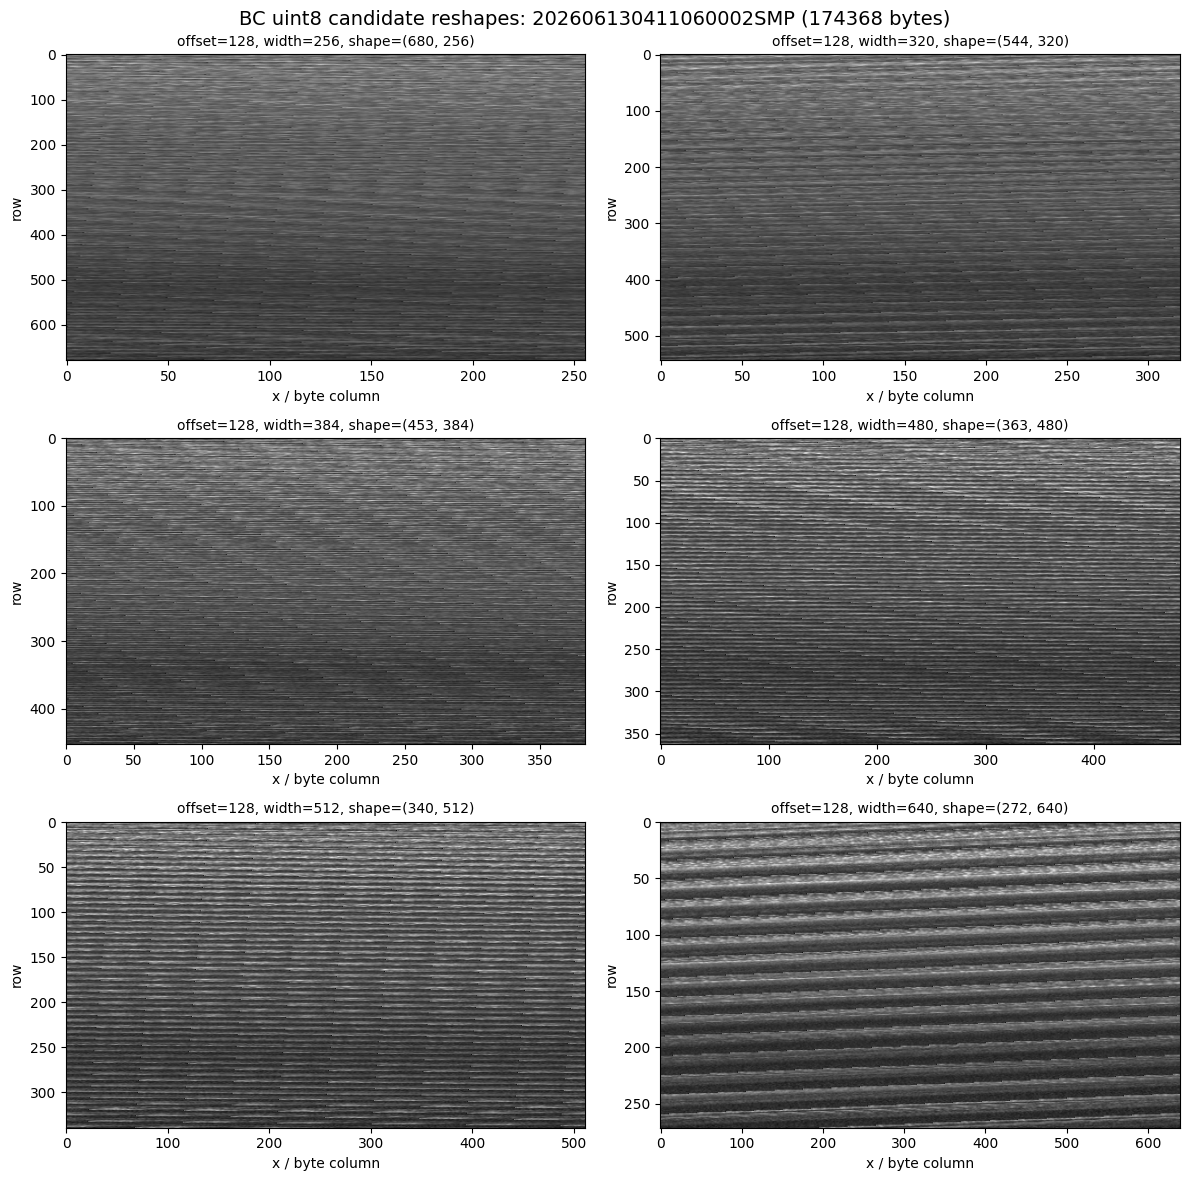

Candidate reshape source
recording_id: 202606130411060002SMP
bc_size_bytes: 174368
offset: 128
bytes_after_offset: 174240
width=256: rows=680, remainder=160
width=320: rows=544, remainder=160
width=384: rows=453, remainder=288
width=480: rows=363, remainder=0
width=512: rows=340, remainder=160
width=640: rows=272, remainder=160


In [12]:
plot_bc_candidate_reshapes(
    bc_inventory_df=bc_inventory_df,
    recording_id="202606130411060002SMP",
    offset=128,
    widths=[256, 320, 384, 480, 512, 640],
    max_rows=None,
)

### First reshape interpretation

Result classification: useful positive result.

The first uint8 reshape test did not produce an obviously validated anatomical B-mode frame, but it did show structured horizontal texture rather than random noise.

The most important result is that the payload length after offset `128` is `174,240` bytes. This equals `288 * 605`.

This matches candidate little-endian `uint16` values seen near the end of the likely header:

- `0x0120` = `288`
- `0x025D` = `605`

Working hypothesis:

- BC header/control region length: `128` bytes
- candidate payload shape: `605 rows x 288 columns`
- candidate payload dtype: `uint8`

This is stronger evidence than the broad width sweep, because the candidate dimensions appear to be encoded in the header and exactly match the post-header payload length.

In [13]:
def read_bc_candidate_dimensions_from_header(byte_data):
    """
    Read candidate uint16 dimensions from the likely BC header.

    Based on observed bytes near offset 0x7C:
    - bytes 124..125 as little-endian uint16
    - bytes 126..127 as little-endian uint16
    """
    dim_a = int.from_bytes(byte_data[124:126], "little")
    dim_b = int.from_bytes(byte_data[126:128], "little")

    return dim_a, dim_b


def plot_header_implied_bc_images(bc_inventory_df, recording_ids=None, offset=128):
    """
    Plot BC uint8 candidate images using dimensions implied by the header.
    """
    present_df = bc_inventory_df[bc_inventory_df["has_bc_cine"]].copy()

    if recording_ids is None:
        standard_size = int(present_df["bc_size_bytes"].mode().iloc[0])
        selected_df = present_df[present_df["bc_size_bytes"] == standard_size].head(3)
    else:
        selected_df = present_df[present_df["recording_id"].isin(recording_ids)].copy()

    n = len(selected_df)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))

    if n == 1:
        axes = np.array([axes])

    summary_rows = []

    for row_idx, (_, row) in enumerate(selected_df.iterrows()):
        byte_data = Path(row["bc_path"]).read_bytes()

        dim_a, dim_b = read_bc_candidate_dimensions_from_header(byte_data)
        payload = byte_data[offset:]
        expected_pixels = dim_a * dim_b

        can_reshape = len(payload) >= expected_pixels

        summary_rows.append(
            {
                "recording_id": row["recording_id"],
                "bc_size_bytes": row["bc_size_bytes"],
                "offset": offset,
                "bytes_after_offset": len(payload),
                "header_dim_a": dim_a,
                "header_dim_b": dim_b,
                "dim_product": expected_pixels,
                "payload_matches_dim_product": len(payload) == expected_pixels,
                "can_reshape": can_reshape,
            }
        )

        if not can_reshape:
            axes[row_idx, 0].set_title(f"{row['recording_id']} cannot reshape")
            axes[row_idx, 0].axis("off")
            axes[row_idx, 1].axis("off")
            continue

        image = np.frombuffer(payload[:expected_pixels], dtype=np.uint8).reshape(dim_b, dim_a)

        axes[row_idx, 0].imshow(image, cmap="gray", aspect="equal")
        axes[row_idx, 0].set_title(f"{row['recording_id']}\nshape=({dim_b}, {dim_a}), aspect=equal")
        axes[row_idx, 0].set_xlabel("x")
        axes[row_idx, 0].set_ylabel("y")

        axes[row_idx, 1].imshow(image, cmap="gray", aspect="auto")
        axes[row_idx, 1].set_title("same data, aspect=auto")
        axes[row_idx, 1].set_xlabel("x")
        axes[row_idx, 1].set_ylabel("y")

    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)

    return summary_df


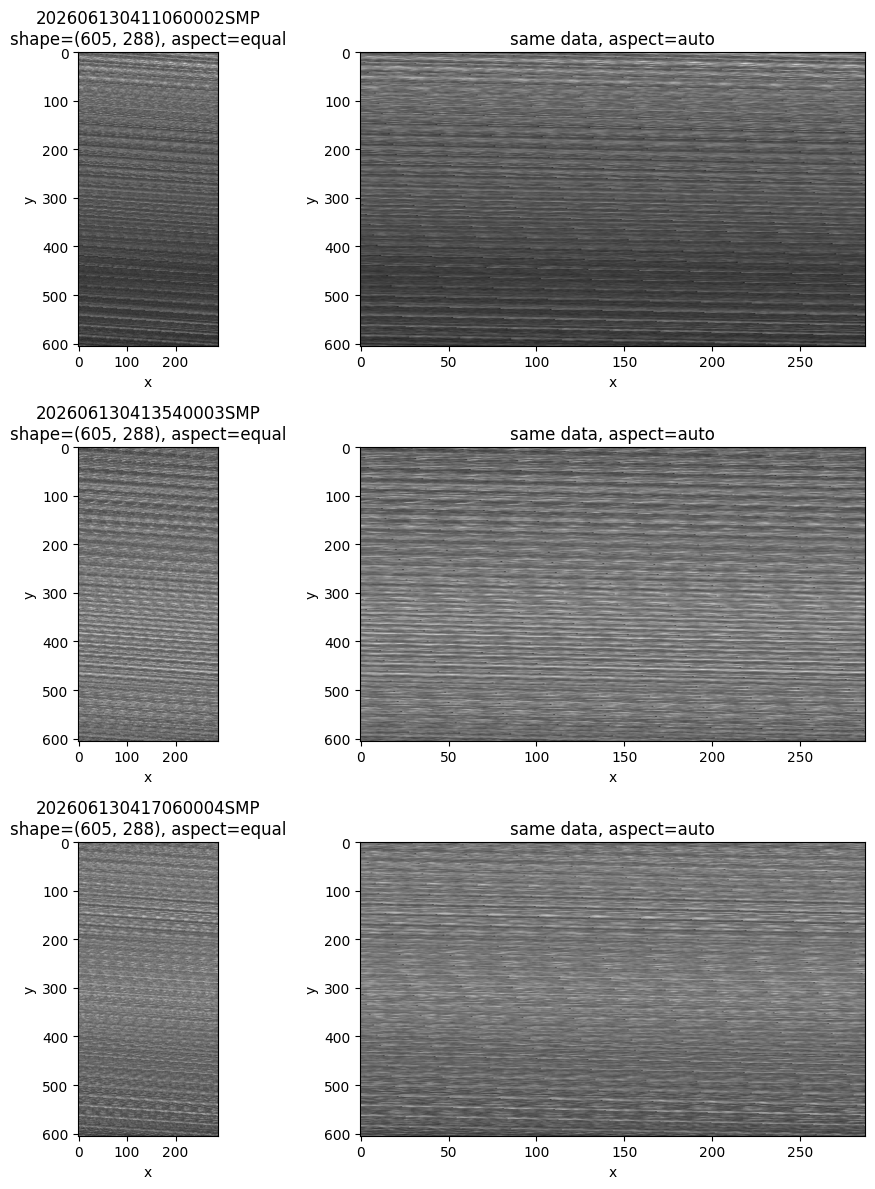

,recording_id,bc_size_bytes,offset,bytes_after_offset,header_dim_a,header_dim_b,dim_product,payload_matches_dim_product,can_reshape
0,202606130411060002SMP,174368,128,174240,288,605,174240,True,True
1,202606130413540003SMP,174368,128,174240,288,605,174240,True,True
2,202606130417060004SMP,174368,128,174240,288,605,174240,True,True


In [14]:
bc_header_shape_summary_df = plot_header_implied_bc_images(
    bc_inventory_df=bc_inventory_df,
    recording_ids=[
        "202606130411060002SMP",
        "202606130413540003SMP",
        "202606130417060004SMP",
    ],
    offset=128,
)

### Header-implied reshape interpretation

Result classification: useful positive result.

The header-implied dimensions exactly match the post-header payload:

- offset: `128`
- bytes after offset: `174,240`
- header dimensions: `288 x 605`
- dimension product: `174,240`

The resulting arrays are not random. They show repeatable raster-like texture and horizontal banding across multiple recordings.

This is evidence that `BC_CinePartition1.bin` contains a structured uint8 payload with dimensions encoded in the header.

Current interpretation:

- validated structure: header + `288 x 605` uint8 payload for standard-size files,
- candidate content type: raster-like / image-like buffer,
- not yet validated: anatomical B-mode image, crop, mask, compressed/decompressed frame, or display-ready ultrasound frame.

Next validation should compare this native BC candidate against the linked AVI B-mode region or inspect whether the exception file follows the same header rule with different dimensions.

In [15]:
def inspect_bc_header_dimensions_all(bc_inventory_df, offset=128):
    """
    Inspect header-implied dimensions for all BC files.

    Current observed rule:
    - payload starts at offset 128
    - bytes 124..125 are little-endian uint16 dim_a
    - bytes 126..127 are little-endian uint16 dim_b
    - payload length should equal dim_a * dim_b for a simple uint8 raster
    """
    rows = []

    for _, row in bc_inventory_df[bc_inventory_df["has_bc_cine"]].iterrows():
        byte_data = Path(row["bc_path"]).read_bytes()

        dim_a = int.from_bytes(byte_data[124:126], "little")
        dim_b = int.from_bytes(byte_data[126:128], "little")
        payload_len = len(byte_data) - offset
        dim_product = dim_a * dim_b

        rows.append(
            {
                "recording_id": row["recording_id"],
                "bc_size_bytes": len(byte_data),
                "offset": offset,
                "bytes_after_offset": payload_len,
                "header_dim_a": dim_a,
                "header_dim_b": dim_b,
                "dim_product": dim_product,
                "payload_matches_dim_product": payload_len == dim_product,
                "payload_minus_dim_product": payload_len - dim_product,
                "size_field_le_u32_at_8": int.from_bytes(byte_data[8:12], "little"),
                "size_field_matches_file_size": int.from_bytes(byte_data[8:12], "little") == len(byte_data),
                "u32_at_0": int.from_bytes(byte_data[0:4], "little"),
                "u32_at_4": int.from_bytes(byte_data[4:8], "little"),
                "u32_at_12": int.from_bytes(byte_data[12:16], "little"),
            }
        )

    result_df = pd.DataFrame(rows).sort_values("recording_id").reset_index(drop=True)

    print("BC header dimension validation")
    print("=" * 80)
    print(f"Rows: {len(result_df)}")
    print(f"Payload matches dim product: {int(result_df['payload_matches_dim_product'].sum())}/{len(result_df)}")
    print(f"Size field matches file size: {int(result_df['size_field_matches_file_size'].sum())}/{len(result_df)}")
    print()

    display(result_df)

    print()
    print("Dimension counts:")
    display(
        result_df
        .groupby(["header_dim_a", "header_dim_b", "payload_matches_dim_product"])
        .size()
        .reset_index(name="count")
    )

    return result_df


In [16]:
bc_header_dimension_all_df = inspect_bc_header_dimensions_all(
    bc_inventory_df=bc_inventory_df,
    offset=128,
)

BC header dimension validation
Rows: 10
Payload matches dim product: 9/10
Size field matches file size: 10/10



,recording_id,bc_size_bytes,offset,bytes_after_offset,header_dim_a,header_dim_b,dim_product,payload_matches_dim_product,payload_minus_dim_product,size_field_le_u32_at_8,size_field_matches_file_size,u32_at_0,u32_at_4,u32_at_12
0,202606130411060002SMP,174368,128,174240,288,605,174240,True,0,174368,True,21,269719,0
1,202606130413540003SMP,174368,128,174240,288,605,174240,True,0,174368,True,33,624314,0
2,202606130417060004SMP,174368,128,174240,288,605,174240,True,0,174368,True,56,1008752,0
3,202606130420260005SMP,174368,128,174240,288,605,174240,True,0,174368,True,65,1405235,0
4,202606130422440006SMP,174368,128,174240,288,605,174240,True,0,174368,True,71,1686812,0
5,202606130426500007SMP,174368,128,174240,288,605,174240,True,0,174368,True,96,2176698,0
6,202606130430380008SMP,174368,128,174240,288,605,174240,True,0,174368,True,122,2605819,0
7,202606130433280009SMP,174368,128,174240,288,605,174240,True,0,174368,True,134,2974079,0
8,202606130434130010SMP,174368,128,174240,288,605,174240,True,0,174368,True,138,3064473,0
9,202606130437480012SMP,232088,128,231960,240,605,145200,False,86760,232088,True,158,3495049,16777216



Dimension counts:


,header_dim_a,header_dim_b,payload_matches_dim_product,count
0,240,605,False,1
1,288,605,True,9


### BC header dimension validation interpretation

Result classification: useful positive result.

The header-dimension rule is validated for the nine standard-size BC files:

- full file size: `174,368` bytes
- payload offset: `128`
- bytes after offset: `174,240`
- header dimensions: `288 x 605`
- dimension product: `174,240`

This supports a working parser for standard BC files:

```text
header/control region: 128 bytes
payload: uint8 raster-like array with shape (605, 288)

In [17]:
def compute_row_col_diagnostics(image):
    """
    Compute simple diagnostics for a 2D uint8 candidate raster.
    """
    image_float = image.astype(np.float32)

    row_means = image_float.mean(axis=1)
    col_means = image_float.mean(axis=0)

    row_std = image_float.std(axis=1)
    col_std = image_float.std(axis=0)

    row_diff = np.abs(np.diff(image_float, axis=0))
    col_diff = np.abs(np.diff(image_float, axis=1))

    diagnostics = {
        "shape_rows": image.shape[0],
        "shape_cols": image.shape[1],
        "mean_intensity": float(image_float.mean()),
        "std_intensity": float(image_float.std()),
        "row_mean_std": float(row_means.std()),
        "col_mean_std": float(col_means.std()),
        "mean_abs_row_diff": float(row_diff.mean()),
        "mean_abs_col_diff": float(col_diff.mean()),
        "row_to_col_diff_ratio": float(row_diff.mean() / col_diff.mean()) if col_diff.mean() > 0 else np.nan,
    }

    return diagnostics, row_means, col_means, row_std, col_std


def compare_correct_width_vs_neighbors(bc_inventory_df, recording_id, offset=128, widths=None):
    """
    Compare row/column diagnostics for the header-implied width and nearby wrong widths.
    """
    if widths is None:
        widths = [240, 256, 288, 320, 384]

    row = bc_inventory_df[bc_inventory_df["recording_id"] == recording_id].iloc[0]
    byte_data = Path(row["bc_path"]).read_bytes()
    payload = byte_data[offset:]

    rows = []

    for width in widths:
        n_pixels = (len(payload) // width) * width
        image = np.frombuffer(payload[:n_pixels], dtype=np.uint8).reshape(-1, width)

        diagnostics, _, _, _, _ = compute_row_col_diagnostics(image)
        diagnostics["recording_id"] = recording_id
        diagnostics["width"] = width
        diagnostics["n_rows"] = image.shape[0]
        diagnostics["remainder"] = len(payload) % width
        diagnostics["payload_exactly_divisible"] = len(payload) % width == 0

        rows.append(diagnostics)

    diagnostics_df = pd.DataFrame(rows)

    display(
        diagnostics_df[
            [
                "recording_id",
                "width",
                "n_rows",
                "remainder",
                "payload_exactly_divisible",
                "mean_intensity",
                "std_intensity",
                "row_mean_std",
                "col_mean_std",
                "mean_abs_row_diff",
                "mean_abs_col_diff",
                "row_to_col_diff_ratio",
            ]
        ]
    )

    return diagnostics_df


def plot_bc_row_col_profiles(bc_inventory_df, recording_ids=None, offset=128):
    """
    Plot row and column mean profiles for standard header-implied BC rasters.
    """
    present_df = bc_inventory_df[bc_inventory_df["has_bc_cine"]].copy()

    if recording_ids is None:
        standard_size = int(present_df["bc_size_bytes"].mode().iloc[0])
        selected_df = present_df[present_df["bc_size_bytes"] == standard_size].head(3)
    else:
        selected_df = present_df[present_df["recording_id"].isin(recording_ids)].copy()

    n = len(selected_df)
    fig, axes = plt.subplots(n, 3, figsize=(15, 3.5 * n))

    if n == 1:
        axes = np.array([axes])

    summary_rows = []

    for row_idx, (_, row) in enumerate(selected_df.iterrows()):
        byte_data = Path(row["bc_path"]).read_bytes()
        dim_a = int.from_bytes(byte_data[124:126], "little")
        dim_b = int.from_bytes(byte_data[126:128], "little")

        payload = byte_data[offset:]
        image = np.frombuffer(payload[: dim_a * dim_b], dtype=np.uint8).reshape(dim_b, dim_a)

        diagnostics, row_means, col_means, row_std, col_std = compute_row_col_diagnostics(image)
        diagnostics["recording_id"] = row["recording_id"]
        summary_rows.append(diagnostics)

        axes[row_idx, 0].imshow(image, cmap="gray", aspect="auto")
        axes[row_idx, 0].set_title(f"{row['recording_id']}\nshape=({dim_b}, {dim_a})")
        axes[row_idx, 0].set_xlabel("x")
        axes[row_idx, 0].set_ylabel("y")

        axes[row_idx, 1].plot(row_means)
        axes[row_idx, 1].set_title("Row mean profile")
        axes[row_idx, 1].set_xlabel("row")
        axes[row_idx, 1].set_ylabel("mean intensity")

        axes[row_idx, 2].plot(col_means)
        axes[row_idx, 2].set_title("Column mean profile")
        axes[row_idx, 2].set_xlabel("column")
        axes[row_idx, 2].set_ylabel("mean intensity")

    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)

    return summary_df

,recording_id,width,n_rows,remainder,payload_exactly_divisible,mean_intensity,std_intensity,row_mean_std,col_mean_std,mean_abs_row_diff,mean_abs_col_diff,row_to_col_diff_ratio
0,202606130411060002SMP,240,726,0,True,88.023758,27.579010,19.640402,0.471384,35.799740,4.036839,8.868261
1,202606130411060002SMP,256,680,160,False,88.055069,27.572004,19.171900,0.302111,36.428173,4.037347,9.022799
2,202606130411060002SMP,288,605,0,True,88.023758,27.579010,18.236170,0.308333,36.879536,4.037164,9.135010
3,202606130411060002SMP,320,544,160,False,88.055069,27.572004,17.400343,0.364853,36.864590,4.037375,9.130830
4,202606130411060002SMP,384,453,288,False,88.077332,27.569038,15.747952,0.517244,34.442623,4.038473,8.528626


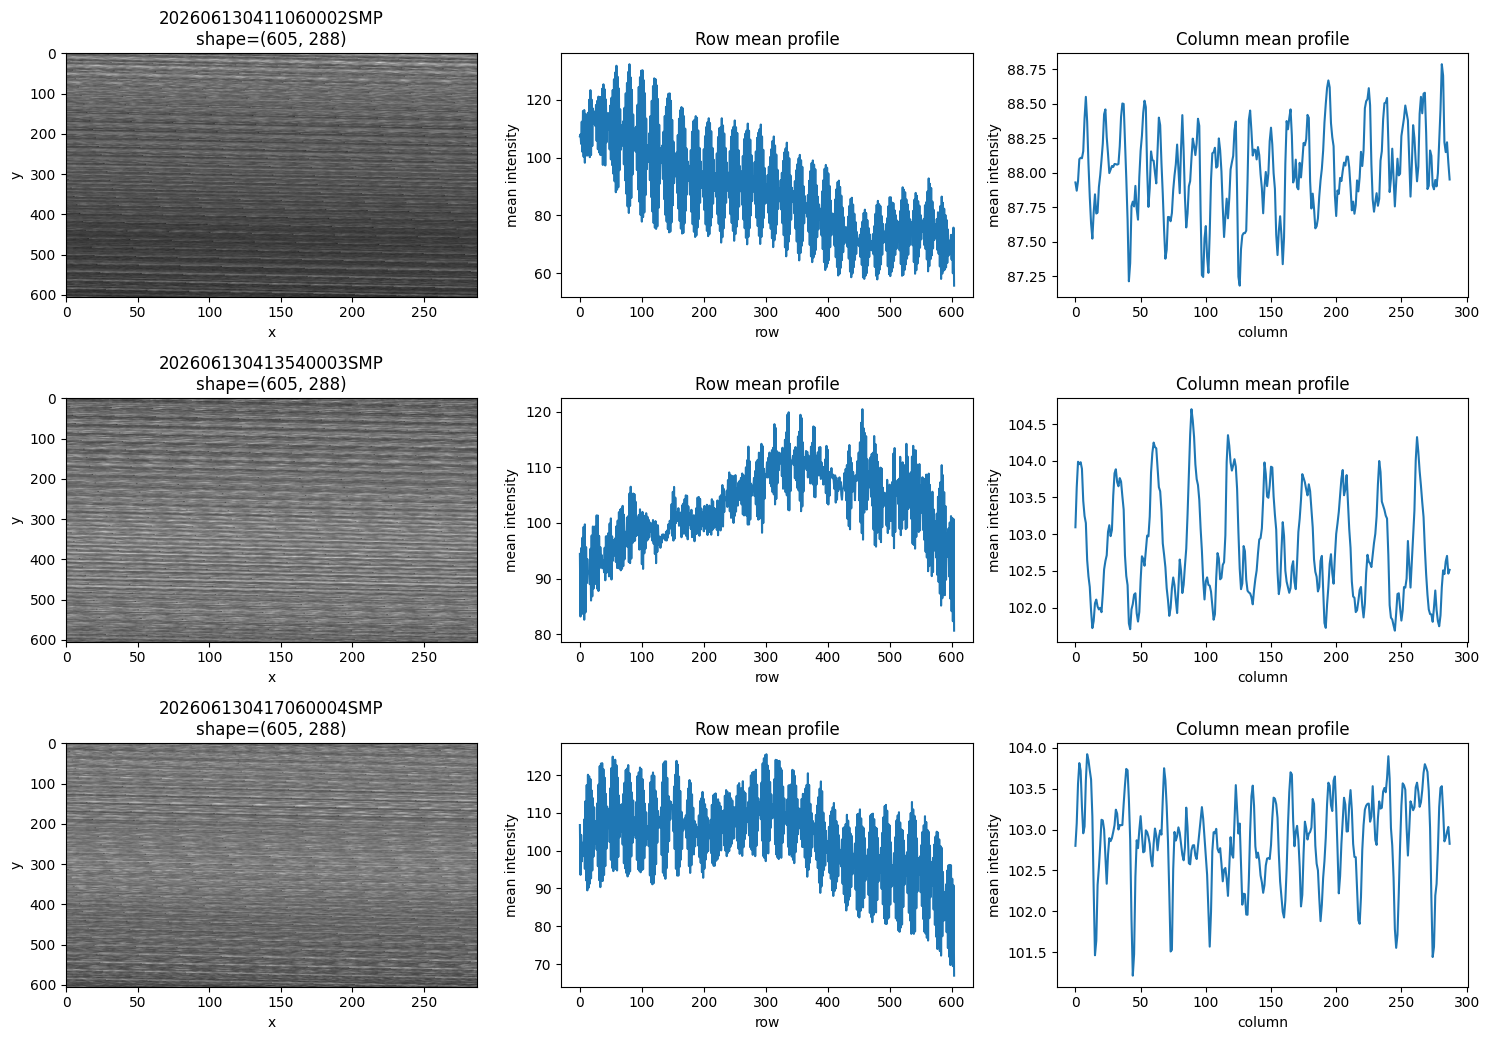

,shape_rows,shape_cols,mean_intensity,std_intensity,row_mean_std,col_mean_std,mean_abs_row_diff,mean_abs_col_diff,row_to_col_diff_ratio,recording_id
0,605,288,88.023758,27.579010,18.236170,0.308333,36.879536,4.037164,9.135010,202606130411060002SMP
1,605,288,102.807579,19.851946,7.144011,0.718106,20.261520,4.702065,4.309069,202606130413540003SMP
2,605,288,102.881531,22.380571,11.849237,0.529095,29.009342,4.914729,5.902531,202606130417060004SMP


In [18]:
bc_width_comparison_df = compare_correct_width_vs_neighbors(
    bc_inventory_df=bc_inventory_df,
    recording_id="202606130411060002SMP",
    offset=128,
    widths=[240, 256, 288, 320, 384],
)

bc_row_col_profile_df = plot_bc_row_col_profiles(
    bc_inventory_df=bc_inventory_df,
    recording_ids=[
        "202606130411060002SMP",
        "202606130413540003SMP",
        "202606130417060004SMP",
    ],
    offset=128,
)

### Row and column structure interpretation

Result classification: useful positive result.

The header-implied `605 x 288` BC payloads show structured raster-like texture rather than random noise.

Row mean profiles show strong row-dependent intensity structure, including broad trends and periodic modulation. Column mean profiles are comparatively flat, with much smaller variation.

This suggests that the payload has meaningful row structure and that the header-implied dimensions are plausible. However, the content does not yet look like a validated display-ready B-mode ultrasound frame.

Current evidence supports:

```text
standard BC files contain a structured uint8 raster-like payload
offset = 128
shape = (605, 288)

## Native BC candidate versus linked AVI frame

This section compares the header-implied BC raster candidate against linked AVI frames from the same recording.

Main goal:

- load the native BC candidate raster,
- load first/middle/last linked AVI frames,
- compare them side by side,
- check whether the BC raster resembles any visible B-mode or static image region in the AVI.

Important:

This is visual validation only. A visual resemblance would make the BC raster a stronger image-like candidate, but it would not yet prove full native image decoding.

In [19]:
def read_standard_bc_raster(bc_path, offset=128):
    """
    Read a standard BC file as a header-implied uint8 raster.
    """
    byte_data = Path(bc_path).read_bytes()

    dim_x = int.from_bytes(byte_data[124:126], "little")
    dim_y = int.from_bytes(byte_data[126:128], "little")

    payload = byte_data[offset:]
    expected_pixels = dim_x * dim_y

    if len(payload) < expected_pixels:
        raise ValueError(
            f"Not enough payload bytes: got {len(payload)}, expected {expected_pixels}"
        )

    image = np.frombuffer(payload[:expected_pixels], dtype=np.uint8).reshape(dim_y, dim_x)

    return image, {
        "dim_x": dim_x,
        "dim_y": dim_y,
        "offset": offset,
        "payload_len": len(payload),
        "expected_pixels": expected_pixels,
        "payload_matches": len(payload) == expected_pixels,
    }


def read_avi_frame(avi_path, frame_index):
    """
    Read one BGR AVI frame with OpenCV and return RGB.
    """
    cap = cv2.VideoCapture(str(avi_path))

    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open AVI: {avi_path}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    frame_index = int(np.clip(frame_index, 0, max(frame_count - 1, 0)))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

    ok, frame_bgr = cap.read()
    cap.release()

    if not ok:
        raise RuntimeError(f"Could not read frame {frame_index} from {avi_path}")

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    info = {
        "frame_index": frame_index,
        "frame_count": frame_count,
        "fps": fps,
        "width": width,
        "height": height,
    }

    return frame_rgb, info


def compare_bc_to_avi_frames(bc_inventory_df, recording_id, frame_positions=None):
    """
    Plot one BC raster next to selected linked AVI frames.
    """
    if frame_positions is None:
        frame_positions = ["first", "middle", "last"]

    row = bc_inventory_df[bc_inventory_df["recording_id"] == recording_id].iloc[0]

    bc_image, bc_info = read_standard_bc_raster(row["bc_path"], offset=128)
    avi_path = Path(row["bc_path"]).parents[1] / "linked_avi" / f"{recording_id}.avi"

    probe_cap = cv2.VideoCapture(str(avi_path))
    if not probe_cap.isOpened():
        raise FileNotFoundError(f"Could not open AVI: {avi_path}")
    frame_count = int(probe_cap.get(cv2.CAP_PROP_FRAME_COUNT))
    probe_cap.release()

    frame_indices = []
    for pos in frame_positions:
        if pos == "first":
            frame_indices.append(0)
        elif pos == "middle":
            frame_indices.append(frame_count // 2)
        elif pos == "last":
            frame_indices.append(max(frame_count - 1, 0))
        else:
            frame_indices.append(int(pos))

    avi_frames = []
    avi_infos = []

    for frame_index in frame_indices:
        frame_rgb, frame_info = read_avi_frame(avi_path, frame_index)
        avi_frames.append(frame_rgb)
        avi_infos.append(frame_info)

    n_cols = 1 + len(avi_frames)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

    axes[0].imshow(bc_image, cmap="gray", aspect="auto")
    axes[0].set_title(
        f"Native BC candidate\nshape={bc_image.shape}, offset={bc_info['offset']}"
    )
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    for idx, (frame_rgb, frame_info) in enumerate(zip(avi_frames, avi_infos), start=1):
        axes[idx].imshow(frame_rgb)
        axes[idx].set_title(
            f"AVI frame {frame_info['frame_index']}\n"
            f"{frame_info['width']}x{frame_info['height']}, fps={frame_info['fps']:.2f}"
        )
        axes[idx].set_xlabel("x")
        axes[idx].set_ylabel("y")

    fig.suptitle(f"BC candidate vs linked AVI: {recording_id}", fontsize=14)
    plt.tight_layout()
    plt.show()

    summary = {
        "recording_id": recording_id,
        "bc_path": row["bc_path"],
        "avi_path": str(avi_path),
        "bc_shape": bc_image.shape,
        "bc_info": bc_info,
        "avi_infos": avi_infos,
    }

    print("BC vs AVI comparison summary")
    print("=" * 80)
    print(f"recording_id: {recording_id}")
    print(f"bc_path: {row['bc_path']}")
    print(f"avi_path: {avi_path}")
    print(f"bc_shape: {bc_image.shape}")
    print(f"bc_info: {bc_info}")
    print(f"avi frame infos: {avi_infos}")

    return summary


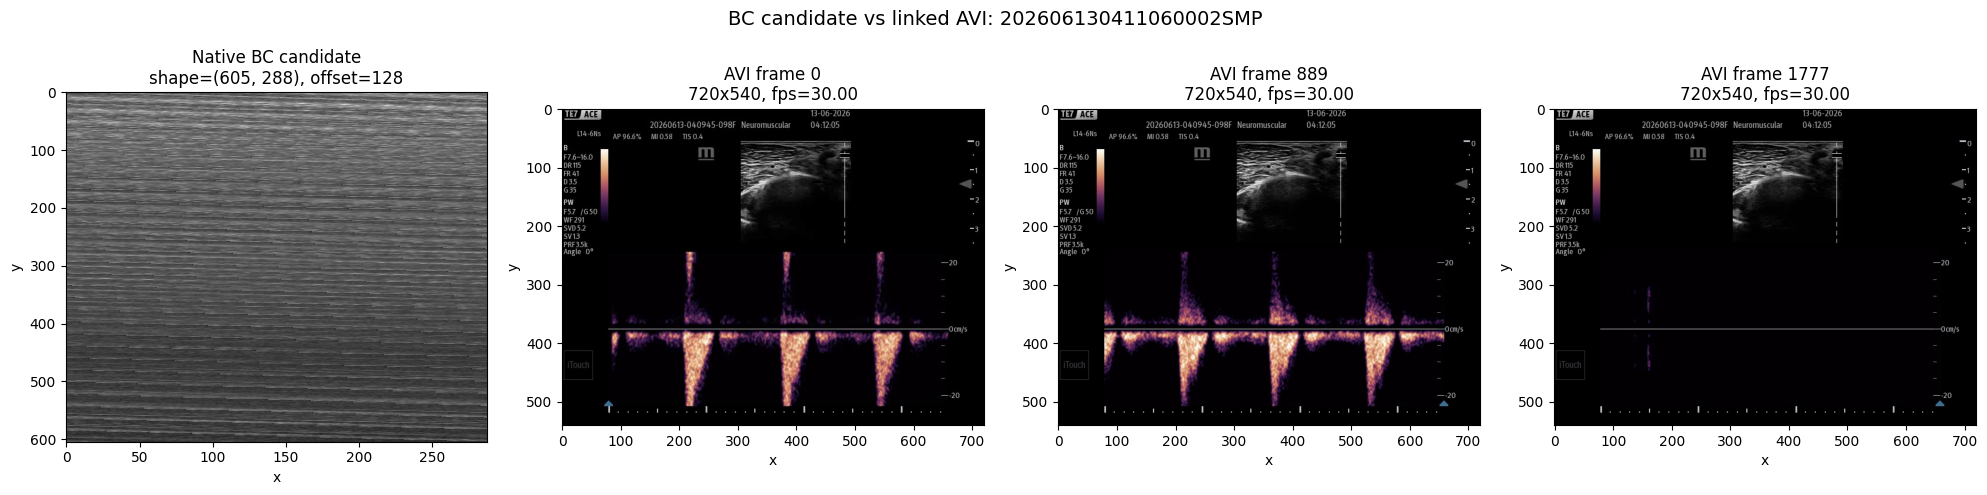

BC vs AVI comparison summary
recording_id: 202606130411060002SMP
bc_path: E:\DopplerLab\ultrasound_recordings\batch_2026_06_13_native\202606130411060002SMP\native\BC_CinePartition1.bin
avi_path: E:\DopplerLab\ultrasound_recordings\batch_2026_06_13_native\202606130411060002SMP\linked_avi\202606130411060002SMP.avi
bc_shape: (605, 288)
bc_info: {'dim_x': 288, 'dim_y': 605, 'offset': 128, 'payload_len': 174240, 'expected_pixels': 174240, 'payload_matches': True}
avi frame infos: [{'frame_index': 0, 'frame_count': 1778, 'fps': 30.0, 'width': 720, 'height': 540}, {'frame_index': 889, 'frame_count': 1778, 'fps': 30.0, 'width': 720, 'height': 540}, {'frame_index': 1777, 'frame_count': 1778, 'fps': 30.0, 'width': 720, 'height': 540}]


In [25]:
bc_avi_comparison_summary = compare_bc_to_avi_frames(
    bc_inventory_df=bc_inventory_df,
    recording_id="202606130411060002SMP",
    frame_positions=["first", "middle", "last"],
)

### BC versus AVI display-frame comparison

Result classification: useful negative result.

The header-implied BC raster does not visually resemble the linked AVI display frame.

The AVI frame contains the full scanner display layout, including B-mode region, PW Doppler spectrum, overlays, and color scale. The BC raster instead appears as a narrow structured grayscale texture with strong horizontal banding.

This argues against the BC payload being a display-ready B-mode frame or a direct crop from the AVI display image.

Current interpretation:

- supported: structured native uint8 raster-like payload,
- not supported: display-ready B-mode frame,
- not supported: direct AVI frame crop,
- still possible: intermediate beamformed/raster buffer, line-based image data, mask, map, or internal processing buffer.

## Cross-recording BC raster comparison

This section compares the nine standard-size BC rasters against each other.

Main goal:

- load all standard `605 x 288` BC rasters,
- inspect them on the same intensity scale,
- compute mean and standard-deviation images across recordings,
- check whether structure is mostly shared or recording-specific.

Important:

This does not validate anatomical image content. It only tests whether the native BC raster behaves like a stable internal pattern or acquisition-dependent image-like data.

In [26]:
def load_standard_bc_rasters(bc_inventory_df, offset=128):
    """
    Load standard-size BC rasters that match header dimensions exactly.
    """
    standard_size = int(bc_inventory_df["bc_size_bytes"].mode().iloc[0])
    standard_df = bc_inventory_df[
        (bc_inventory_df["has_bc_cine"]) & (bc_inventory_df["bc_size_bytes"] == standard_size)].copy()

    images = []
    rows = []

    for _, row in standard_df.iterrows():
        byte_data = Path(row["bc_path"]).read_bytes()

        dim_x = int.from_bytes(byte_data[124:126], "little")
        dim_y = int.from_bytes(byte_data[126:128], "little")
        payload = byte_data[offset:]
        expected = dim_x * dim_y

        if len(payload) != expected:
            continue

        image = np.frombuffer(payload, dtype=np.uint8).reshape(dim_y, dim_x)
        images.append(image.astype(np.float32))

        rows.append(
            {
                "recording_id": row["recording_id"],
                "bc_size_bytes": row["bc_size_bytes"],
                "shape": image.shape,
                "mean": float(image.mean()),
                "std": float(image.std()),
                "min": int(image.min()),
                "max": int(image.max()),
            }
        )

    image_stack = np.stack(images, axis=0)
    summary_df = pd.DataFrame(rows)

    return image_stack, summary_df


def plot_bc_cross_recording_summary(image_stack, summary_df):
    """
    Plot standard BC rasters plus across-recording mean/std images.
    """
    n_images = image_stack.shape[0]

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.reshape(-1)

    vmin = np.percentile(image_stack, 1)
    vmax = np.percentile(image_stack, 99)

    for idx in range(min(n_images, 9)):
        ax = axes[idx]
        ax.imshow(image_stack[idx], cmap="gray", aspect="auto", vmin=vmin, vmax=vmax)
        ax.set_title(summary_df.loc[idx, "recording_id"][-8:])
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.suptitle("Standard BC rasters, shared display scale")
    plt.tight_layout()
    plt.show()

    mean_image = image_stack.mean(axis=0)
    std_image = image_stack.std(axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(mean_image, cmap="gray", aspect="auto")
    axes[0].set_title("Mean BC raster across recordings")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    axes[1].imshow(std_image, cmap="magma", aspect="auto")
    axes[1].set_title("Std image across recordings")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")

    axes[2].plot(mean_image.mean(axis=1), label="mean row profile")
    axes[2].plot(std_image.mean(axis=1), label="std row profile")
    axes[2].set_title("Across-recording row profiles")
    axes[2].set_xlabel("row")
    axes[2].set_ylabel("intensity")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    cross_summary = {
        "n_images": int(image_stack.shape[0]),
        "shape": tuple(image_stack.shape[1:]),
        "global_mean": float(image_stack.mean()),
        "global_std": float(image_stack.std()),
        "mean_of_pixel_std": float(std_image.mean()),
        "max_pixel_std": float(std_image.max()),
    }

    print("Cross-recording BC raster summary")
    print("=" * 80)
    for key, value in cross_summary.items():
        print(f"{key}: {value}")

    display(summary_df)

    return mean_image, std_image, cross_summary

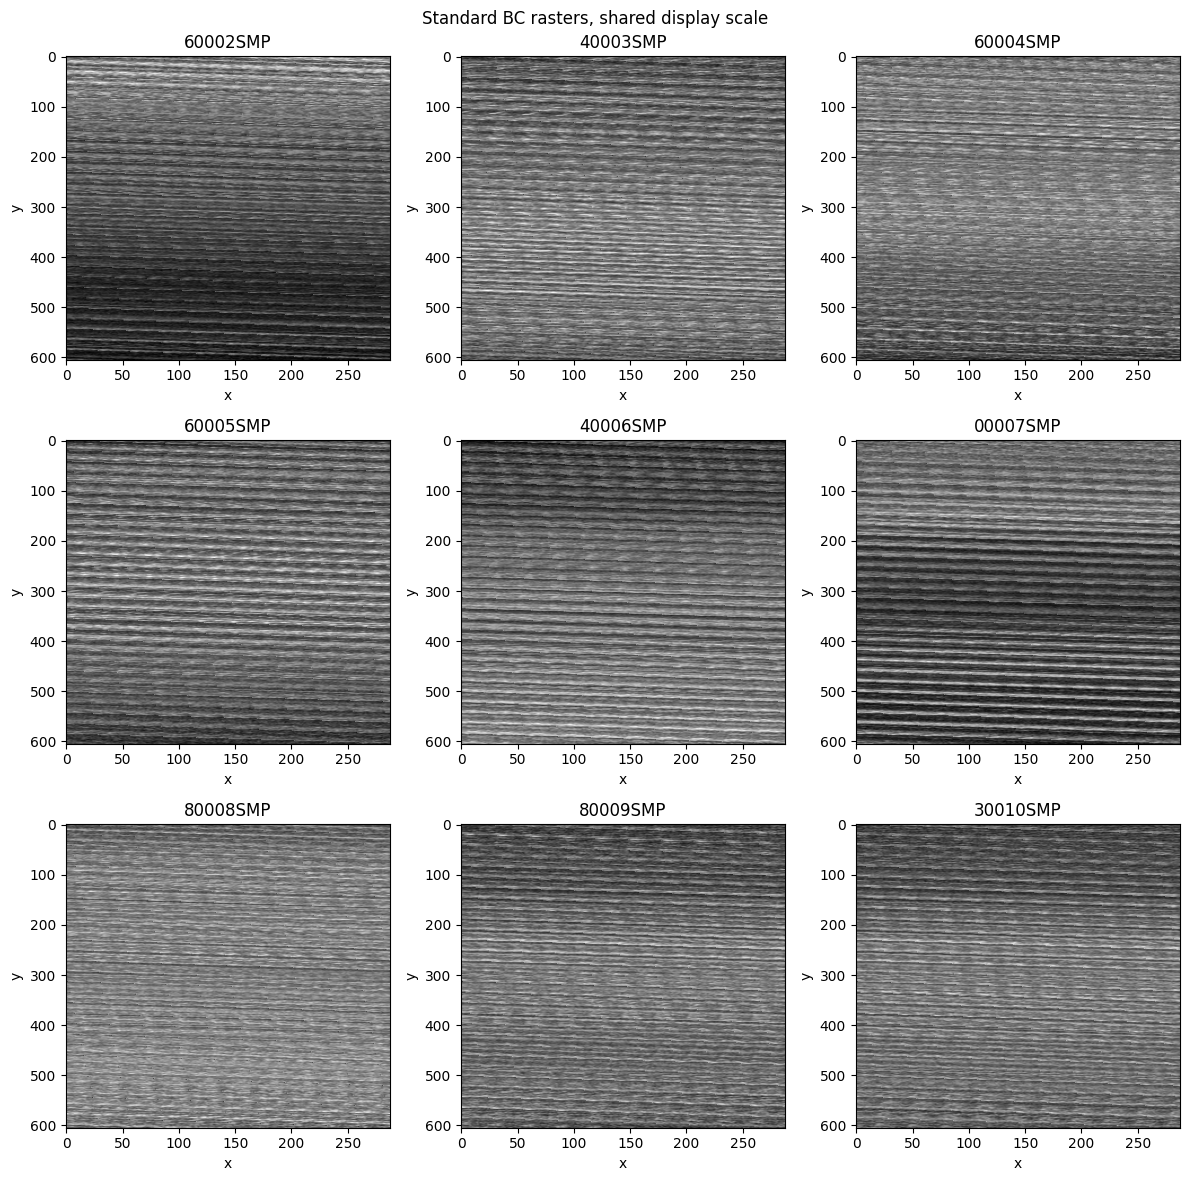

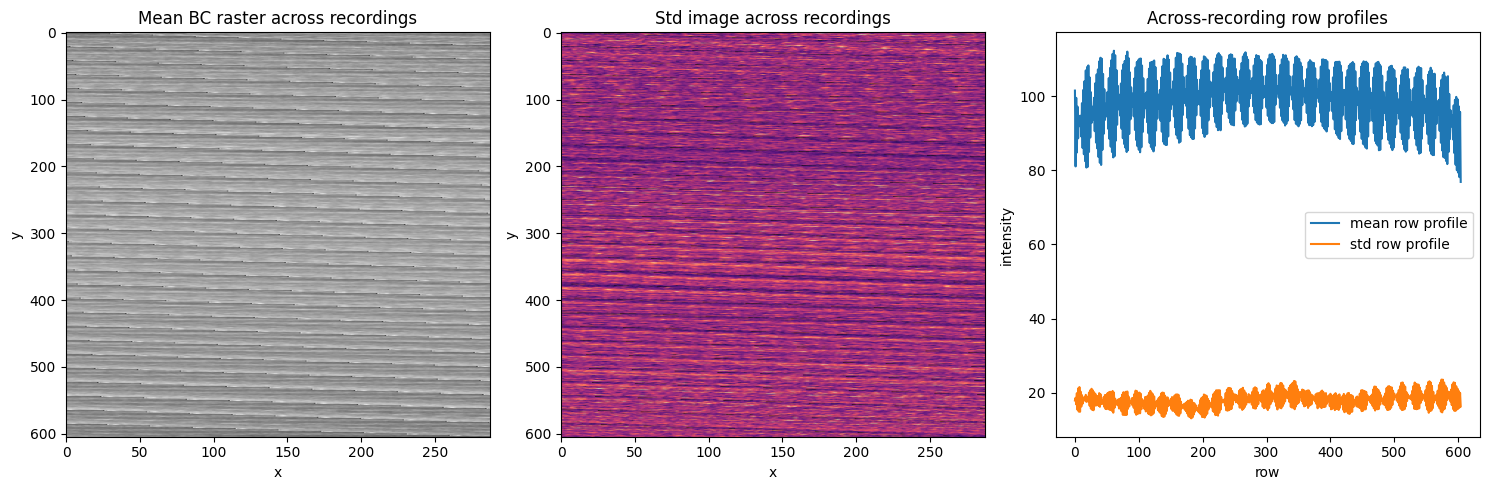

Cross-recording BC raster summary
n_images: 9
shape: (605, 288)
global_mean: 98.7726058959961
global_std: 24.70084571838379
mean_of_pixel_std: 17.92569923400879
max_pixel_std: 41.1378288269043


,recording_id,bc_size_bytes,shape,mean,std,min,max
0,202606130411060002SMP,174368,"(605, 288)",88.023760,27.579011,22,215
1,202606130413540003SMP,174368,"(605, 288)",102.807570,19.851945,24,194
2,202606130417060004SMP,174368,"(605, 288)",102.881531,22.380572,23,200
3,202606130420260005SMP,174368,"(605, 288)",97.982650,23.860442,23,196
4,202606130422440006SMP,174368,"(605, 288)",98.985422,26.754920,26,211
5,202606130426500007SMP,174368,"(605, 288)",91.547842,24.196909,24,199
6,202606130430380008SMP,174368,"(605, 288)",108.467872,19.441883,25,198
7,202606130433280009SMP,174368,"(605, 288)",99.149374,25.206568,23,209
8,202606130434130010SMP,174368,"(605, 288)",99.107398,25.608183,24,207


In [27]:
bc_standard_stack, bc_standard_summary_df = load_standard_bc_rasters(
    bc_inventory_df=bc_inventory_df,
    offset=128,
)

bc_mean_image, bc_std_image, bc_cross_summary = plot_bc_cross_recording_summary(
    image_stack=bc_standard_stack,
    summary_df=bc_standard_summary_df,
)

### Cross-recording BC raster interpretation

Result classification: useful positive result.

The nine standard-size BC rasters share the same validated structure:

```text
offset = 128
shape = (605, 288)
dtype = uint8

## Exception BC file layout inspection

This section inspects the one BC file that does not follow the standard `288 x 605` payload rule.

Main goal:

- parse the first header-implied raster from the exception file,
- inspect the remaining extra bytes,
- test whether the extra block has structured byte distribution,
- visualize the first raster and extra block using conservative reshape guesses.

Important:

The exception file is not used to redefine the standard BC parser. It is inspected separately because it may contain a different layout, extra plane, padding, or acquisition-specific block.

In [28]:
def describe_bytes(byte_data):
    """
    Return compact byte statistics for one byte block.
    """
    values = np.frombuffer(byte_data, dtype=np.uint8)
    counts = np.bincount(values, minlength=256)
    probabilities = counts[counts > 0] / len(values)

    entropy = -np.sum(probabilities * np.log2(probabilities))

    top_bytes = np.argsort(counts)[::-1][:8]
    top_text = ", ".join(
        f"0x{b:02X}:{counts[b] / len(values):.3f}"
        for b in top_bytes
        if counts[b] > 0
    )

    return {
        "n_bytes": len(byte_data),
        "entropy": float(entropy),
        "zero_fraction": float(counts[0] / len(values)),
        "ff_fraction": float(counts[255] / len(values)),
        "unique_values": int((counts > 0).sum()),
        "mean": float(values.mean()),
        "std": float(values.std()),
        "min": int(values.min()),
        "max": int(values.max()),
        "top_bytes": top_text,
    }


def inspect_exception_bc_layout(bc_inventory_df, offset=128):
    """
    Inspect the one non-standard BC file without changing the standard parser.
    """
    present_df = bc_inventory_df[bc_inventory_df["has_bc_cine"]].copy()
    standard_size = int(present_df["bc_size_bytes"].mode().iloc[0])
    exception_df = present_df[present_df["bc_size_bytes"] != standard_size].copy()

    if len(exception_df) != 1:
        raise ValueError(f"Expected one exception file, found {len(exception_df)}")

    row = exception_df.iloc[0]
    byte_data = Path(row["bc_path"]).read_bytes()

    dim_x = int.from_bytes(byte_data[124:126], "little")
    dim_y = int.from_bytes(byte_data[126:128], "little")
    first_raster_len = dim_x * dim_y

    payload = byte_data[offset:]
    first_block = payload[:first_raster_len]
    extra_block = payload[first_raster_len:]

    stats_df = pd.DataFrame(
        [
            {"block": "full_file", **describe_bytes(byte_data)},
            {"block": "payload_after_128", **describe_bytes(payload)},
            {"block": "first_header_raster", **describe_bytes(first_block)},
            {"block": "extra_after_first_raster", **describe_bytes(extra_block)},
        ]
    )

    print("Exception BC layout")
    print("=" * 80)
    print(f"recording_id: {row['recording_id']}")
    print(f"file_size: {len(byte_data)}")
    print(f"size_field_at_8: {int.from_bytes(byte_data[8:12], 'little')}")
    print(f"header dims: {dim_x} x {dim_y}")
    print(f"first_raster_len: {first_raster_len}")
    print(f"payload_len: {len(payload)}")
    print(f"extra_len: {len(extra_block)}")
    print()

    display(stats_df)

    first_image = np.frombuffer(first_block, dtype=np.uint8).reshape(dim_y, dim_x)

    candidate_extra_widths = [120, 180, 240, 288, 360, 480]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.reshape(-1)

    axes[0].imshow(first_image, cmap="gray", aspect="auto")
    axes[0].set_title(f"first raster: {dim_y} x {dim_x}")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    for ax, width in zip(axes[1:], candidate_extra_widths):
        n_pixels = (len(extra_block) // width) * width
        image = np.frombuffer(extra_block[:n_pixels], dtype=np.uint8).reshape(-1, width)

        ax.imshow(image, cmap="gray", aspect="auto")
        ax.set_title(f"extra block width={width}\nshape={image.shape}, rem={len(extra_block) % width}")
        ax.set_xlabel("x")
        ax.set_ylabel("row")

    for ax in axes[1 + len(candidate_extra_widths):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return stats_df

Exception BC layout
recording_id: 202606130437480012SMP
file_size: 232088
size_field_at_8: 232088
header dims: 240 x 605
first_raster_len: 145200
payload_len: 231960
extra_len: 86760



,block,n_bytes,entropy,zero_fraction,ff_fraction,unique_values,mean,std,min,max,top_bytes
0,full_file,232088,5.361530,0.351005,0.000280,247,67.746743,56.040616,0,255,"0x00:0.351, 0x5E:0.012, 0x62:0.011, 0x60:0.011..."
1,payload_after_128,231960,5.362981,0.350729,0.000280,247,67.776431,56.031818,0,255,"0x00:0.351, 0x5E:0.012, 0x62:0.011, 0x60:0.011..."
2,first_header_raster,145200,6.655013,0.000000,0.000000,195,104.804415,25.658025,22,219,"0x5E:0.018, 0x62:0.018, 0x60:0.018, 0x63:0.018..."
3,extra_after_first_raster,86760,0.680088,0.937702,0.000749,102,5.807054,34.019157,0,255,"0x00:0.938, 0x01:0.005, 0xFB:0.004, 0xFC:0.004..."


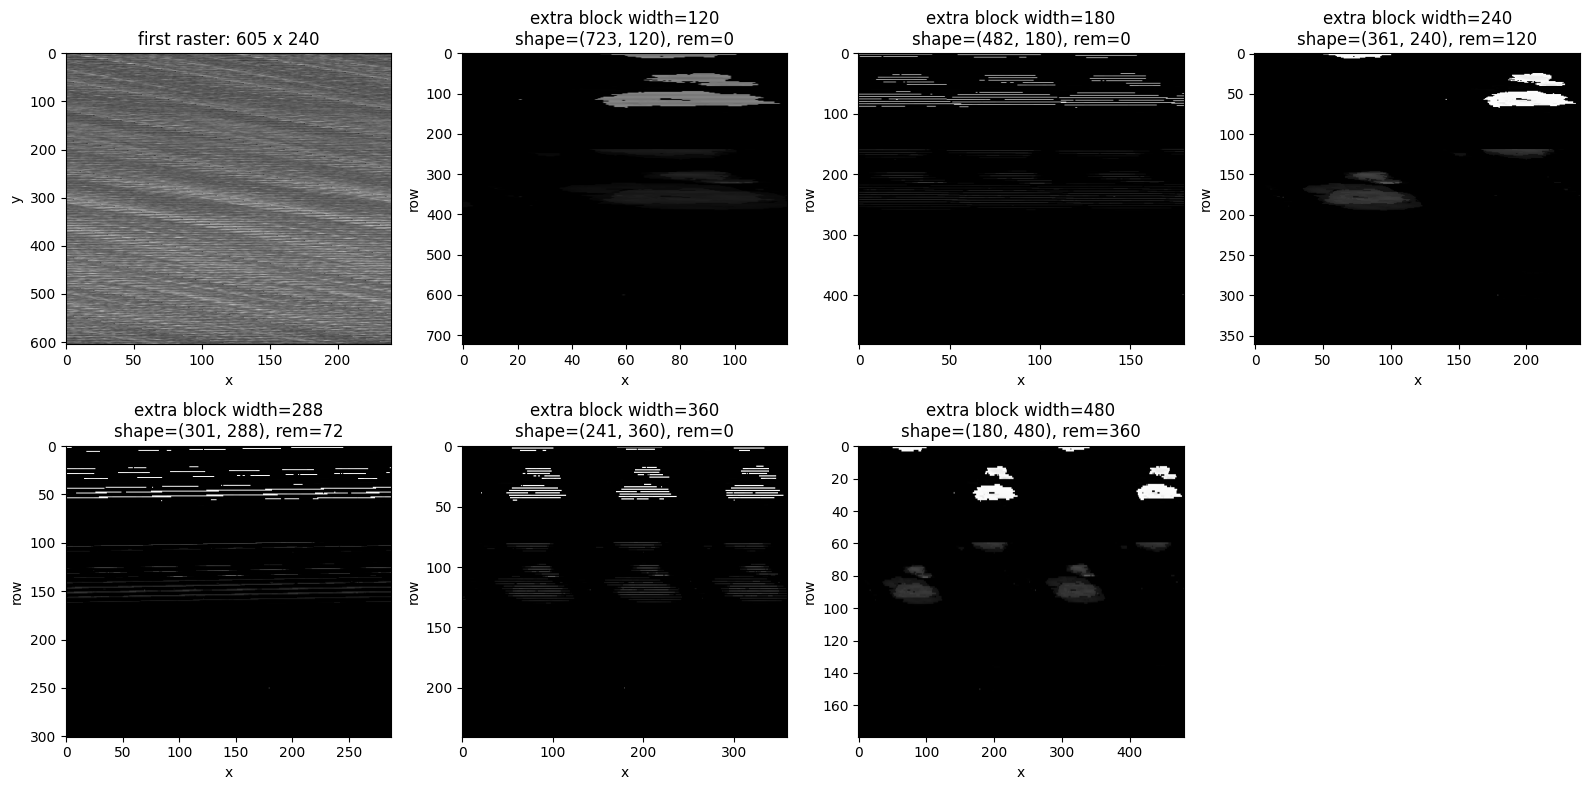

In [29]:
bc_exception_stats_df = inspect_exception_bc_layout(
    bc_inventory_df=bc_inventory_df,
    offset=128,
)

### Exception BC layout interpretation

Result classification: useful positive result.

The exception BC file `202606130437480012SMP` follows the same general header idea but has a different layout.

The first header-implied payload is:

```text
offset = 128
shape = (605, 240)
dtype = uint8
length = 145,200 bytes

## Final checkpoint

NB09 reached a useful exploratory checkpoint for `BC_CinePartition1.bin`.

### Main findings

`BC_CinePartition1.bin` is present in all 10 native recordings.

Nine recordings share the same standard file layout:

```text
file size = 174,368 bytes
header/control region = 128 bytes
payload offset = 128
payload dtype candidate = uint8
payload shape = (605, 288)
payload length = 174,240 bytes
288 * 605 = 174,240